In [1]:
import qutip as qt 
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

In [2]:
plt.rcParams.update({
    "font.family": "Helvetica"
})

%config InlineBackend.figure_formats = ['png']
plt.rcParams.update({'font.size': 8})

%matplotlib inline
plt.rcParams['figure.dpi'] = 300

# Figure 1. Amplifying amplitude errors

In [3]:
uncorrected = np.load('./data/aae/aae_uncorrected.npz')
pops_gatebased = np.load('./data/aae/aae_sim_gatebased.npz')
pops_gatebased_onlyepsilon = np.load('./data/aae/aae_sim_gatebased_onlyepsilon.npz')
corrected_failed = np.load('./data/aae/aae_corrected_failed.npz')
corrected_failed_sim = np.load('./data/aae/aae_sim_corrected_failed.npz')
corrected_succeeded = np.load('./data/aae/aae_corrected_succeeded.npz')
corrected_dragy = np.load('./data/aae/aae_only_dragy.npz')
corrected_dragy_fit = np.load('./data/aae/aae_only_dragy_fit.npz')

Text(0.01, 0.97, '(d)')

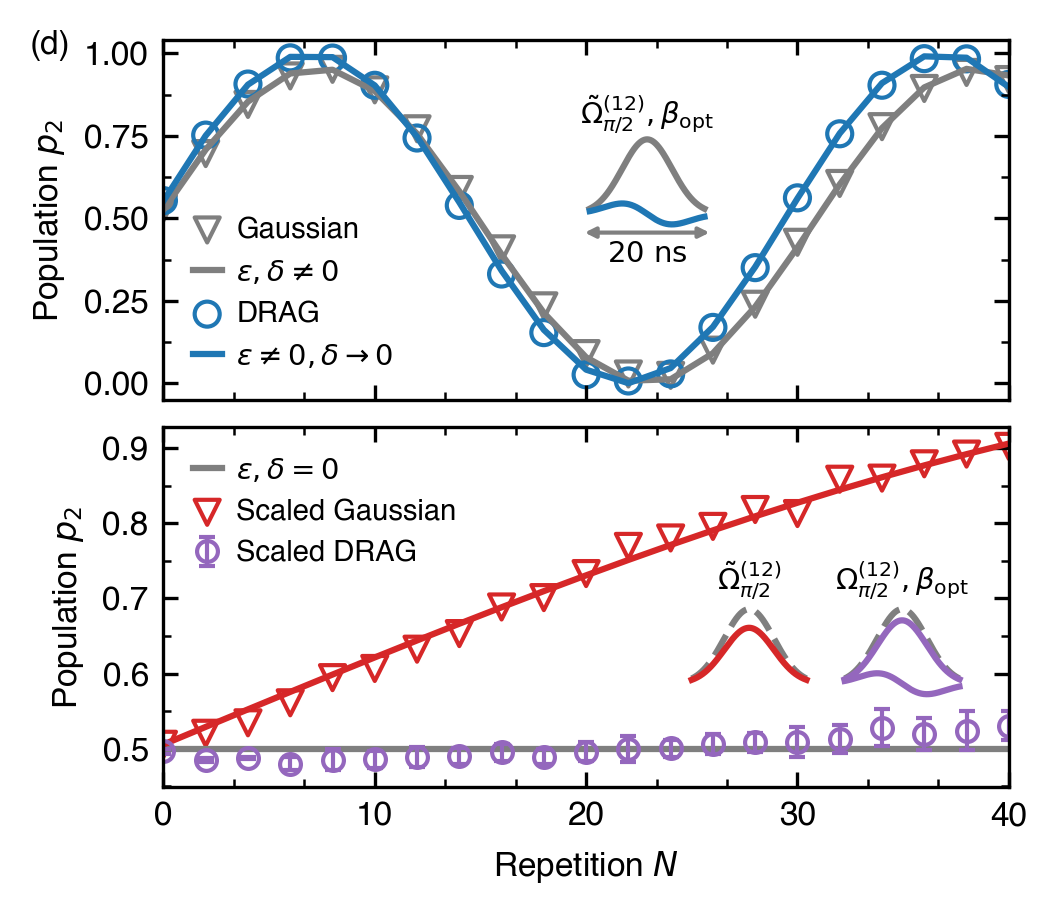

In [4]:
fig, axes = plt.subplots(figsize=(3.4, 2.9), nrows=2, sharex=True, layout="constrained")

axes[0].scatter(
    uncorrected['N'], uncorrected['pop2'],
    label='Gaussian', facecolor='none', edgecolor='tab:gray', marker='v'
)

axes[0].plot(
    pops_gatebased['N'], pops_gatebased['pop2'],
    color='tab:gray', label=r'$\epsilon,\delta\neq 0$'
)

axes[0].scatter(
    uncorrected['N'], corrected_dragy['pop2'],
    label='DRAG', facecolor='none', edgecolor='tab:blue', marker='o'
)

axes[0].plot(
    pops_gatebased_onlyepsilon['N'], corrected_dragy_fit['pop2'],
    color="tab:blue", label=r'$\epsilon\neq0,\delta\to 0$'
)

mean_re_pops = np.mean(corrected_succeeded['pop2s'], axis=0)
std_re_pops = np.std(corrected_succeeded['pop2s'], axis=0)

axes[1].axhline(0.5, color='tab:gray', label=r'$\epsilon,\delta = 0$')

axes[1].plot(
    corrected_failed_sim['N'], corrected_failed_sim['pop2'],
    color='tab:red'
)

axes[1].scatter(
    corrected_failed['N'], corrected_failed['pop2'],
    label='Scaled Gaussian', facecolor='none', edgecolor='tab:red', marker='v'
)

# axes[1].errorbar(
#     corrected_succeeded['N'],
#     mean_re_pops,
#     yerr=std_re_pops,
#     fmt='v',
#     markersize=9,
#     mfc='none',
#     mec='tab:blue',
#     ecolor='tab:blue',
#     elinewidth=0.5,
#     capsize=4,
#     markeredgewidth=2.0,
#     label='Scaling with DRAG'
# )

axes[1].errorbar(
    corrected_succeeded['N'],
    mean_re_pops,
    yerr=std_re_pops,
    fmt='o',
    mfc='none',
    mec='tab:purple',
    ecolor='tab:purple',
    label='Scaled DRAG',
    capsize=2,
    elinewidth=1,
    ms=5
)

# axes[0].set_ylim(-0.1, 1.1)
# axes[0].set_yticks([0, 0.25, 0.5, 0.75, 1.0])
# axes[1].set_ylim(0.48, 0.9)
# axes[1].set_yticks([0.5, 0.75, 1.0])

axes[0].legend(fontsize=7, frameon=False, handlelength=1, handletextpad=0.5, borderpad=0.5)
axes[1].legend(fontsize=7, frameon=False, handlelength=1, handletextpad=0.5, borderpad=0.5)

for ax in axes:
    ax.set_xlim(0, 40)
    ax.set_xticks([0, 10, 20, 30, 40])
    ax.set_ylabel(r'Population $p_2$', fontsize=8)
    ax.tick_params(axis='both', which='major', top=True, right=True, direction='in', labelsize=8)

    # Custom minor ticks
    ax.xaxis.set_minor_locator(AutoMinorLocator(3))   # minor x-ticks every 2 units
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))  # 1 minor tick between each major y-tick
    
    ax.tick_params(axis='both', which='minor', top=True, right=True, direction='in')


axes[1].set_xlabel(r'Repetition $N$', fontsize=8)

"""
Draw Gaussians
"""

ax_inset_1 = fig.add_axes([0.54, 0.76, 0.15, 0.12])  # adjust if needed

# Gaussian data
xg = np.linspace(-3, 3, 400)
sigma = 1.3
yg = np.exp(-0.5 * (xg / sigma)**2)
yg_dotted = 20*np.gradient(yg)

# Plot + subtle fill
ax_inset_1.plot(xg, yg, color='tab:gray')
ax_inset_1.plot(xg, yg_dotted, color='tab:blue')
# ax_inset_1.fill_between(xg, yg, alpha=0.1, color='tab:gray')
# ax_inset_1.fill_between(xg, yg_dotted, alpha=0.5, color='tab:blue')
ax_inset_1.annotate(
    '',
    xy=(-3.7, min(yg_dotted)-0.11),
    xytext=(3.7, min(yg_dotted)-0.11),
    arrowprops=dict(
        arrowstyle='<|-|>',
        color='gray',
        mutation_scale=5
    )
)

ax_inset_1.text(
    0, max(yg)+0.05,
    r'$\tilde\Omega_{\pi/2}^{(12)}, \beta_\text{opt}$',
    ha='center', va='bottom', fontsize=7
)

ax_inset_1.text(
    0, min(yg_dotted)-0.58,
    r'$\text{20 ns}$',
    ha='center', va='bottom', fontsize=7
)

ax_inset_1.set_xlim([-4, 4])
ax_inset_1.set_ylim([-0.3, 1.1])

ax_inset_2 = fig.add_axes([0.64, 0.22, 0.15, 0.12])  

ax_inset_2.plot(xg, yg, color='tab:gray', linestyle='--')
ax_inset_2.plot(xg, 0.75*yg, color='tab:red')
# ax_inset_2.fill_between(xg, yg, alpha=0.1, color='tab:gray')

ax_inset_2.text(
    0, max(yg)+0.1,
    r'$\tilde\Omega_{\pi/2}^{(12)}$',
    ha='center', va='bottom', fontsize=7    
)

ax_inset_2.set_xlim([-4, 4])
ax_inset_2.set_ylim([-0.3, 1.1])

ax_inset_3 = fig.add_axes([0.79, 0.22, 0.15, 0.12])  

ax_inset_3.plot(xg, yg, color='tab:gray', linestyle='--')
ax_inset_3.plot(xg, 0.85*yg, color='tab:purple')
ax_inset_3.plot(xg, yg_dotted, color='tab:purple')
# ax_inset_3.fill_between(xg, yg_dotted, alpha=0.5, color='tab:purple')
# ax_inset_3.fill_between(xg, yg, alpha=0.1, color='tab:gray')

ax_inset_3.text(
    0, max(yg)+0.1,
    r'$\Omega_{\pi/2}^{(12)}, \beta_\text{opt}$',
    ha='center', va='bottom', fontsize=7    
)

ax_inset_3.set_xlim([-4, 4])
ax_inset_3.set_ylim([-0.3, 1.1])

for ax_inset in [ax_inset_1, ax_inset_2, ax_inset_3]:
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    for spine in ax_inset.spines.values():
        spine.set_visible(False)

fig.text(0.01, 0.97, '(d)', fontsize=8)
# fig.savefig('./figures/main/fig1d.pdf', format='pdf', bbox_inches=0)

### QuTiP Bloch sphere

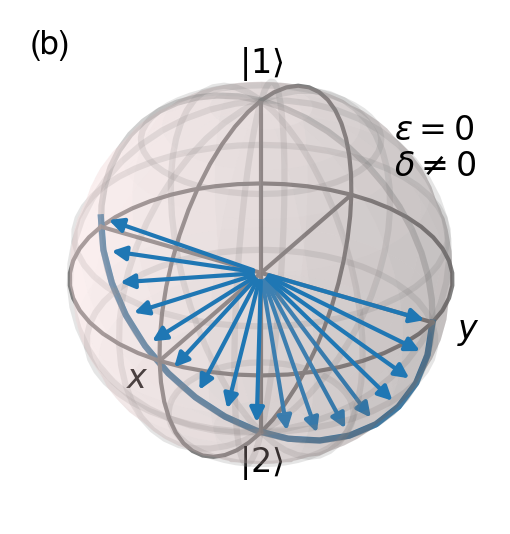

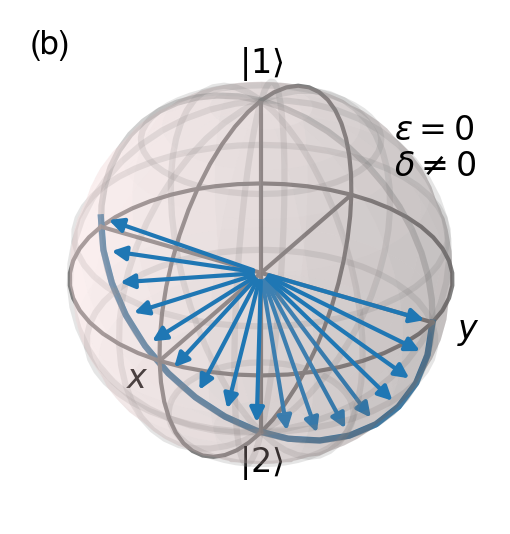

In [5]:
# Define parameters
epsilon = 0.05
delta = 0
N_max = 17
from qutip import *
# Pauli matrices
sx, sy, sz = sigmax(), sigmay(), sigmaz()

# Initial state: (|0> + i|1>) / sqrt(2)
psi0 = (basis(2, 0) + 1j * basis(2, 1)).unit()

# Imperfect pi/2 rotation
theta = (np.pi / 2 + epsilon) / 2
U = (1j * theta * sx + 1j * delta * sz).expm()
U2 = U * U

# Initialize Bloch sphere
b = Bloch(figsize=(1.5, 1.5))
b.vector_mutation = 7

# Compute evolved states
states = []
bloch_coords = []
for N in [2 * n for n in range(N_max)]:
    psi_N = (U2 ** N) * psi0
    states.append(psi_N)
    x = expect(sx, psi_N)
    y = expect(sy, psi_N)
    z = expect(sz, psi_N)
    bloch_coords.append([x, y, z])

# Set all vector colors to blue
b.vector_color = ['tab:blue' for _ in range(len(states))]

# Add Bloch vectors
b.add_states(states)

# Add trajectory line
xs, ys, zs = zip(*bloch_coords)
b.add_points([xs, ys, zs], meth='l', colors=['tab:blue' for _ in range(len(states))]) 

# Display the Bloch sphere
b.make_sphere()
b.font_size = 8
b.zlabel = [r'$|1\rangle$', r'$|2\rangle$']
b.vector_width = 1
b.fig.text(0, 1, '(b)', fontsize=8)
b.fig.text(0.81, 0.81, r'$\epsilon=0$', fontsize=8)
b.fig.text(0.81, 0.73, r'$\delta\neq 0$', fontsize=8)
# b.fig.tight_layout()
b.show()
# b.fig.savefig('./figures/main/fig1b_bloch.pdf', format='pdf', transparent=False, bbox_inches='tight', pad_inches=0.0)

C:\Users\tng-admin\AppData\Local\Temp\ipykernel_5768\4023597486.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  b.fig.tight_layout()


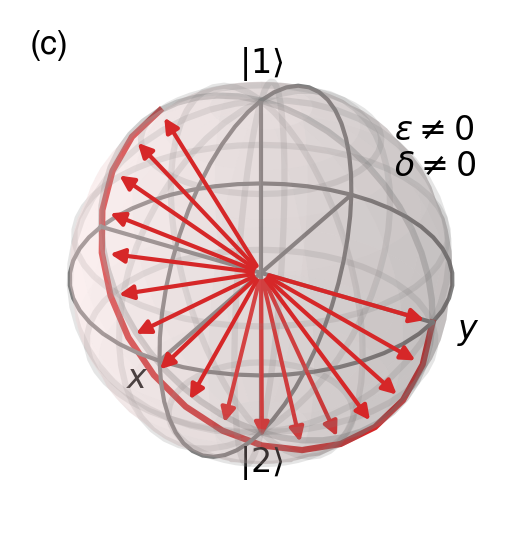

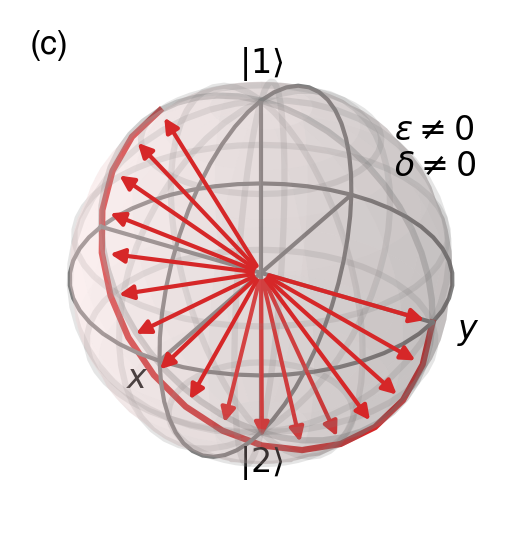

In [6]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
epsilon = 0.05
delta = 0.1
N_max = 17

# Pauli matrices
sx, sy, sz = sigmax(), sigmay(), sigmaz()

# Initial state: (|0> + i|1>) / sqrt(2)
psi0 = (basis(2, 0) + 1j * basis(2, 1)).unit()

# Imperfect pi/2 rotation
theta = (np.pi / 2 + epsilon) / 2
U = (1j * theta * sx + 1j * delta * sz).expm()
U2 = U * U

# Initialize Bloch sphere
b = Bloch(figsize=(1.5, 1.5))
b.vector_mutation = 7

# Compute evolved states
states = []
bloch_coords = []
for N in [2 * n for n in range(N_max)]:
    psi_N = (U2 ** N) * psi0
    states.append(psi_N)
    x = expect(sx, psi_N)
    y = expect(sy, psi_N)
    z = expect(sz, psi_N)
    bloch_coords.append([x, y, z])

# Set all vector colors to blue
b.vector_color = ['tab:red' for _ in range(len(states))]

# Add Bloch vectors
b.add_states(states)

# Add trajectory line
xs, ys, zs = zip(*bloch_coords)
b.add_points([xs, ys, zs], meth='l', colors=['tab:red' for _ in range(len(states))])  # trajectory as a line

# Display the Bloch sphere
b.make_sphere()
b.font_size = 8
b.zlabel = [r'$|1\rangle$', r'$|2\rangle$']
b.vector_width = 1
b.fig.text(0.81, 0.81, r'$\epsilon\neq 0$', fontsize=8)
b.fig.text(0.81, 0.73, r'$\delta\neq 0$', fontsize=8)
b.fig.text(0, 1, '(c)', fontsize=8)
b.fig.tight_layout()
b.show()
# b.fig.savefig('./figures/main/fig1c_bloch.pdf', format='pdf', transparent=False, bbox_inches='tight', pad_inches=0.0)

## Errors considering

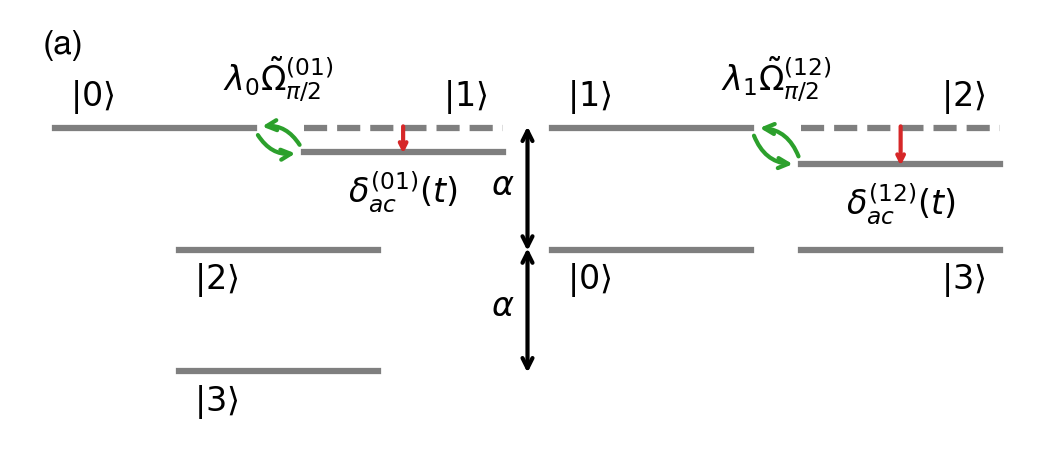

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(3.4, 1.3), layout='constrained')

anharmonicity = -0.5
E_A = 0.0
E_B = 0.0
E_C = anharmonicity
E_D = anharmonicity

half_len = 0.12

x_A = 0.75
x_B = 1.05
x_C = 0.75
x_D = 1.05

# Plot horizontal energy levels

stark_shift_12 = 0.15
ax.plot([x_A - half_len, x_A + half_len], [E_A, E_A], color='tab:gray')
ax.plot([x_B - half_len, x_B + half_len], [E_B, E_B], color='tab:gray', linestyle='dashed')
ax.plot([x_B - half_len, x_B + half_len], [E_B - stark_shift_12, E_B - stark_shift_12], color='tab:gray')
ax.plot([x_C - half_len, x_C + half_len], [E_C, E_C], color='tab:gray')
ax.plot([x_D - half_len, x_D + half_len], [E_D, E_D], color='tab:gray')

# Labels
ax.text(x_A - 0.075, E_A + 0.05, r'$|1\rangle$', ha='center', va='bottom', fontsize=8)
ax.text(x_B + 0.075, E_B + 0.05, r'$|2\rangle$', ha='center', va='bottom', fontsize=8)
ax.text(x_C - 0.075, E_C - 0.2, r'$|0\rangle$', ha='center', va='bottom', fontsize=8)
ax.text(x_D + 0.075, E_D - 0.2, r'$|3\rangle$', ha='center', va='bottom', fontsize=8)

ax.annotate(
    '',
    xy=(0.6, E_C-0.04),
    xytext=(0.6, E_A+0.04),
    arrowprops=dict(
        arrowstyle='<->',
        color='k',
        mutation_scale=6
    )
)

ax.text(
    0.57, (E_A + E_C) / 2 - 0.05,
    r'$\alpha$',
    ha='center', va='bottom', fontsize=8
)

ax.annotate(
    '',
    xy=(x_B, E_B+0.04),
    xytext=(x_B, E_B-stark_shift_12-0.04),
    arrowprops=dict(
        arrowstyle='<-',
        color='tab:red',
        mutation_scale=4
    )
)

ax.text(
    x_B, E_B-stark_shift_12-0.25,
    r'$\delta^{(12)}_{ac}(t)$',
    ha='center', va='bottom', fontsize=8
)

# === Curved arrows between |1> and |2> ===
arrow_below = FancyArrowPatch(
    posA=(x_A + half_len, E_A),
    posB=(x_B - half_len, E_B - stark_shift_12),
    connectionstyle="arc3,rad=0.4",  # curve downward
    arrowstyle='->',
    mutation_scale=6,
    color='tab:green',
    linewidth=1
)
arrow_above = FancyArrowPatch(
    posA=(x_A + half_len, E_A),
    posB=(x_B - half_len, E_B - stark_shift_12),
    connectionstyle="arc3,rad=-0.4",  # reflection (curve upward)
    arrowstyle='<-',
    mutation_scale=6,
    color='tab:green',
    linewidth=1
)

ax.add_patch(arrow_below)
ax.add_patch(arrow_above)

# Optional label
ax.text((x_A + x_B) / 2, E_A + 0.1, r'$\lambda_1\tilde{\Omega}^{(12)}_{\pi/2}$', ha='center', va='bottom', fontsize=8)

##### LEFT SIDE

E0 = 0.0
E1 = 0.0
E2 = anharmonicity
E3 = 2*anharmonicity

half_len_L = 0.12

x0 = 0.15
x1 = 0.45
x2 = 0.3
x3 = 0.3

stark_shift_01 = 0.1
ax.plot([x0 - half_len_L, x0 + half_len_L], [E0, E0], color='tab:gray')
ax.plot([x1 - half_len_L, x1 + half_len_L], [E1,E1], color='tab:gray', linestyle='dashed')
ax.plot([x1 - half_len_L, x1 + half_len_L], [E1-stark_shift_01, E1-stark_shift_01], color='tab:gray')
ax.plot([x2 - half_len_L, x2 + half_len_L], [E2, E2], color='tab:gray')
ax.plot([x3 - half_len_L, x3 + half_len_L], [E3, E3], color='tab:gray')

# Labels (left)
ax.text(x0 - 0.075, E0 + 0.05, r'$|0\rangle$', ha='center', va='bottom', fontsize=8)
ax.text(x1 + 0.075, E1 + 0.05, r'$|1\rangle$', ha='center', va='bottom', fontsize=8)
ax.text(x2 - 0.075, E2 - 0.2, r'$|2\rangle$', ha='center', va='bottom', fontsize=8)
ax.text(x3 - 0.075, E3 - 0.2, r'$|3\rangle$', ha='center', va='bottom', fontsize=8)

ax.annotate(
    '',
    xy=(0.6, E3-0.04),
    xytext=(0.6, E2+0.04),
    arrowprops=dict(
        arrowstyle='<->',
        color='k',
        mutation_scale=6
    )
)

ax.text(
    0.57, (E2 + E3) / 2 - 0.05,
    r'$\alpha$',
    ha='center', va='bottom', fontsize=8
)

# === Curved arrows between |1> and |2> ===
arrow_below_01 = FancyArrowPatch(
    posA=(x0 + half_len, E0),
    posB=(x1 - half_len, E1 - stark_shift_01),
    connectionstyle="arc3,rad=0.4",  # curve downward
    arrowstyle='->',
    mutation_scale=6,
    color='tab:green',
    linewidth=1
)
arrow_above_01 = FancyArrowPatch(
    posA=(x0 + half_len, E0),
    posB=(x1 - half_len, E1 - stark_shift_01),
    connectionstyle="arc3,rad=-0.4",  # reflection (curve upward)
    arrowstyle='<-',
    mutation_scale=6,
    color='tab:green',
    linewidth=1
)

ax.text((x0 + x1) / 2, E0 + 0.1, r'$\lambda_0\tilde{\Omega}^{(01)}_{\pi/2}$', ha='center', va='bottom', fontsize=8)

ax.add_patch(arrow_below_01)
ax.add_patch(arrow_above_01)

ax.annotate(
    '',
    xy=(x1, E1+0.04),
    xytext=(x1, E1-stark_shift_01-0.04),
    arrowprops=dict(
        arrowstyle='<-',
        color='tab:red',
        mutation_scale=4
    )
)

ax.text(
    x1, E1-stark_shift_01-0.25,
    r'$\delta^{(01)}_{ac}(t)$',
    ha='center', va='bottom', fontsize=8
)

# Clean up axis

# ax.axvline(1.2)
# ax.axvline(0)
ax.set_xlim(0, 1.2)
# ax.set_ylim(-1.6, 0.6)
ax.set_xticks([])
ax.set_yticks([])
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.025, 0.97, '(a)', fontsize=8)

# fig.savefig('./figures/main/energy_diagram.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Figure 2. Amplifying phase errors

In [8]:
def Ux(angle, delta):
 theta = (angle + epsilon) / 2
 return (1j * theta * sx + 1j * delta * sz).expm()

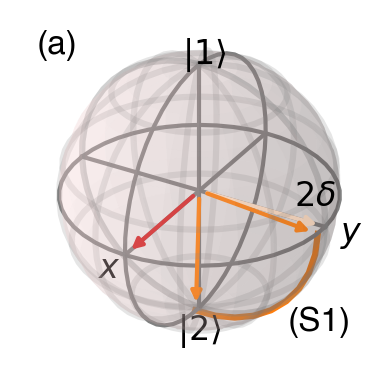

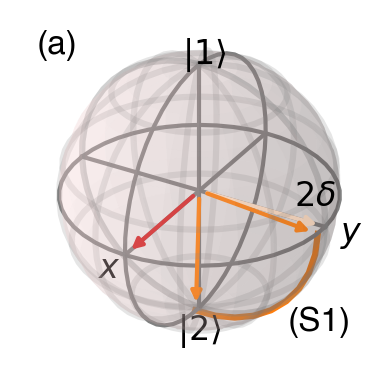

In [9]:
epsilon = 0
delta = 0.04

psi0 = (basis(2, 0) + 1j * basis(2, 1)).unit()

theta = (np.pi / 2 + epsilon) / 2

# Initialize Bloch sphere
b = Bloch(figsize=(1.1, 1.1))
b.vector_mutation = 5
b.vector_width = 1

states = []
bloch_coords = []

psi1 = Ux(np.pi/2, delta)*psi0

for angle in np.linspace(0, np.pi/2, 10):
    psi_N = Ux(-angle, delta)*psi1
    x = expect(sx, psi_N)
    y = expect(sy, psi_N)
    z = expect(sz, psi_N)
    bloch_coords.append([x, y, z])

states.append(psi1)
states.append(Ux(-np.pi/2, delta)*psi1)
psi_axis = (basis(2, 0) + basis(2, 1)).unit()
states.append(psi_axis)
states.append(psi0)

b.vector_color = ['tab:orange' for _ in range(len(states)-2)]
b.vector_color.append('tab:red')
b.vector_color.append('#FFDFC3')

xs, ys, zs = zip(*bloch_coords)
b.add_points([xs, ys, zs], meth='l', colors=['tab:orange' for _ in range(len(states))])  # trajectory as a line

# Add Bloch vectors
b.add_states(states)

# Display the Bloch sphere
b.make_sphere()
b.font_size = 8
b.zlabel = [r'', r'$|2\rangle$']
b.fig.text(0.46, 0.9, r'$|1\rangle$', fontsize=8)
b.fig.text(0.78, 0.09, r'(S1)', fontsize=8)  # Unicode for circled 1
b.fig.text(0.8, 0.47, r'$2\delta$', fontsize=8)  # Unicode for circled 1
b.fig.text(0.02, 0.93, '(a)', fontsize=8)
b.show()
# b.fig.savefig('./figures/main/fig3_step1.pdf', format='pdf', transparent=False, bbox_inches='tight', pad_inches=0.0)

C:\Users\tng-admin\AppData\Local\Temp\ipykernel_5768\1830657894.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  b.fig.tight_layout()


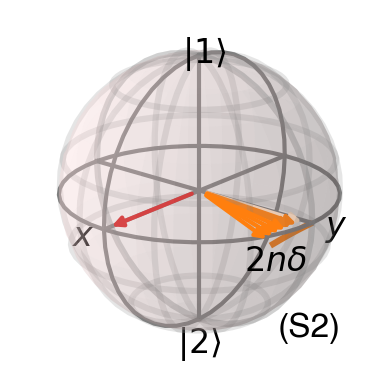

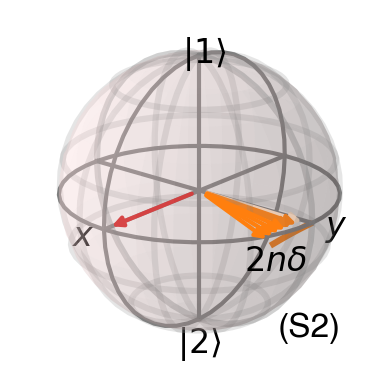

In [10]:
epsilon = 0
delta = 0.011
N_max = 1

psi0 = (basis(2, 0) + 1j * basis(2, 1)).unit()

b = Bloch(figsize=(1.1, 1.1))
b.vector_mutation = 5
b.vector_width = 1

states = []
bloch_coords = []

for N in [2*n+1 for n in range(7)]:
    psi_N = (Ux(-np.pi/2, delta)*Ux(np.pi/2, delta))**N * psi0
    x = expect(sx, psi_N)
    y = expect(sy, psi_N)
    z = expect(sz, psi_N)
    states.append(psi_N)
    bloch_coords.append([x, y, z])

psi_axis = (basis(2, 0) + basis(2, 1)).unit()
states.append(psi_axis)
b.vector_color = ['tab:orange' for _ in range(len(states)-1)]
b.vector_color[0] = '#FFDFC3'
b.vector_color.append('tab:red')

xs, ys, zs = zip(*bloch_coords)
b.add_points([xs, ys, zs], meth='l', colors=['tab:orange' for _ in range(len(states))])  # trajectory as a line

# Add Bloch vectors
b.add_states(states)
b.view = [-50, 20]
# Display the Bloch sphere
b.make_sphere()
b.font_size = 8
b.zlabel = [r'', r'$|2\rangle$']
b.fig.text(0.75, 0.07, '(S2)', fontsize=8)  # Unicode for circled 1
b.fig.text(0.65, 0.27, r'$2n\delta$', fontsize=8)
b.fig.text(0.46, 0.9, r'$|1\rangle$', fontsize=8)
b.fig.tight_layout()
b.show()
# b.fig.savefig('./figures/main/fig3_step2.pdf', format='pdf', transparent=False, bbox_inches='tight', pad_inches=0.0)

C:\Users\tng-admin\AppData\Local\Temp\ipykernel_5768\750116156.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  b.fig.tight_layout()


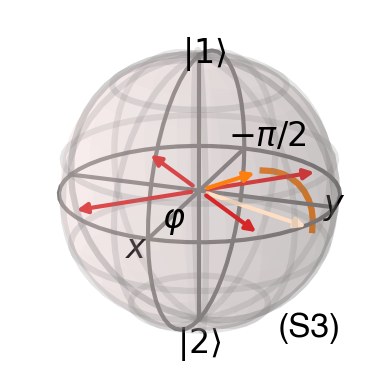

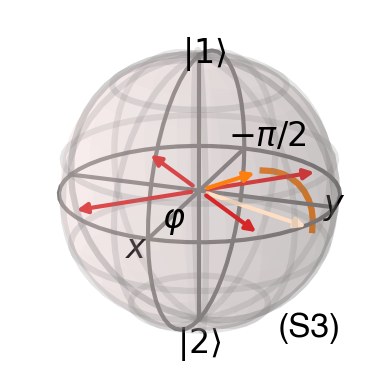

In [11]:
epsilon = 0
delta = 0.01

psi0 = (basis(2, 0) + 1j * basis(2, 1)).unit()

theta = (np.pi / 2 + epsilon) / 2

def Uy(angle, delta):
 theta = (angle + epsilon) / 2
 return (1j * theta * (1/np.sqrt(2))*(sx+sy) + 1j * delta * sz).expm()

b = Bloch(figsize=(1.1, 1.1))
b.vector_mutation = 5
b.vector_width = 1

states = []
bloch_coords = []

psi1 = (Ux(-np.pi/2, delta)*Ux(np.pi/2, delta))**13 * psi0

for angle in np.linspace(0, np.pi/2, 10):
    psi_N = Uy(-angle, delta)*psi1
    x = expect(sx, psi_N)
    y = expect(sy, psi_N)
    z = expect(sz, psi_N)
    bloch_coords.append([x, y, z])

states.append(psi1)
states.append(Uy(-np.pi/2, delta)*psi1)
psi_axis = ((1/np.sqrt(2))*basis(2, 0) + (np.exp(1j*np.pi/4)/np.sqrt(2))*basis(2, 1)).unit()
states.append(psi_axis)
psi_axis = ((1/np.sqrt(2))*basis(2, 0) - (np.exp(1j*np.pi/4)/np.sqrt(2))*basis(2, 1)).unit()
states.append(psi_axis)
psi_axis = ((1/np.sqrt(2))*basis(2, 0) - (np.exp(1j*3*np.pi/4)/np.sqrt(2))*basis(2, 1)).unit()
states.append(psi_axis)
psi_axis = ((1/np.sqrt(2))*basis(2, 0) + (np.exp(1j*3*np.pi/4)/np.sqrt(2))*basis(2, 1)).unit()
states.append(psi_axis)

# b.vector_color = ['tab:orange' for _ in range(len(states))]
b.vector_color.append('#FFDFC3')
b.vector_color.append('tab:orange')
b.vector_color.append('tab:red')
b.vector_color.append('tab:red')
b.vector_color.append('tab:red')
b.vector_color.append('tab:red')

xs, ys, zs = zip(*bloch_coords)
b.add_points([xs, ys, zs], meth='l', colors=['tab:orange' for _ in range(len(states))])  # trajectory as a line

# Add Bloch vectors
b.add_states(states)
b.view = [-70, 20]
# Display the Bloch sphere
b.make_sphere()
b.font_size = 8
b.zlabel = [r'', r'$|2\rangle$']
b.ylpos = [1, -1.2]
b.fig.text(0.75, 0.07, '(S3)', fontsize=8)  # Unicode for circled 1
b.fig.text(0.4, 0.40, r'$\varphi$', fontsize=8)
b.fig.text(0.46, 0.9, r'$|1\rangle$', fontsize=8)
b.fig.text(0.6, 0.65, r'$-\pi/2$', fontsize=8)
b.fig.tight_layout()
b.show()
# b.fig.savefig('./figures/main/fig3_step3.pdf', format='pdf', transparent=False, bbox_inches='tight', pad_inches=0.0)

In [13]:
ape_data = np.load('./data/ape/ape_data.npz')
angle_swept = ape_data['angle_swept']
ape_pops = ape_data['pe_pops']

ape_data

NpzFile './data/ape/ape_data.npz' with keys: angle_swept, pe_pops

In [14]:
ape_fits = np.load('./data/ape/ape_data_fit.npz')

ape_fits

NpzFile './data/ape/ape_data_fit.npz' with keys: angle_swept, pe_fits

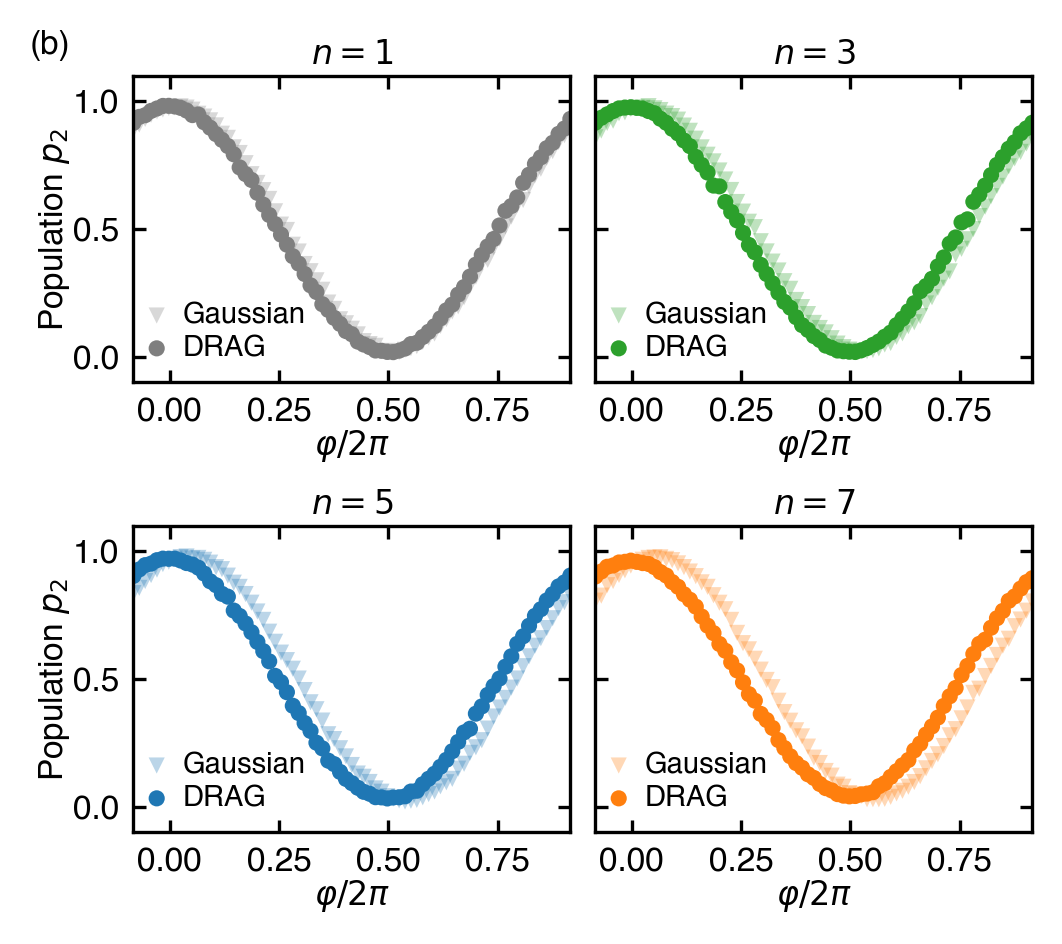

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(3.4, 3), sharey='row', layout='constrained')
axes = axes.flatten()

n_labels = [r'$n=1$', r'$n=3$', r'$n=5$', r'$n=7$']
colors = ['tab:gray', 'tab:green', 'tab:blue', 'tab:orange']
skip = 1

for i, ax in enumerate(axes):
    # Uncorrected data
    ax.scatter(
        angle_swept[::skip] / (2 * np.pi),
        ape_pops[i][:, 0][::skip],
        s=15, color=colors[i], alpha=0.3,
        marker='v', label='Gaussian', edgecolors='none'
    )

    ax.scatter(
        angle_swept[::skip] / (2 * np.pi),
        ape_pops[i + 4][:, 0][::skip],
        s=15, color=colors[i],
        marker='o', label='DRAG', edgecolors='none'
    )

    ax.set_xlim(min(angle_swept / (2 * np.pi)), max(angle_swept / (2 * np.pi)))
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel(r'$\varphi / 2\pi$', fontsize=8, labelpad=0)
    ax.set_title(n_labels[i], fontsize=8, pad=3)
    ax.tick_params(axis='both', which='major', top=True, right=True,
                   length=3, direction='in', labelsize=8)
    ax.legend(fontsize=7, frameon=False, handlelength=0.2, labelspacing=0.2, borderpad=0.2, loc='lower left')

# Shared y-axis labels per row
axes[0].set_ylabel(r'Population $p_2$', fontsize=8, labelpad=0)
axes[2].set_ylabel(r'Population $p_2$', fontsize=8, labelpad=0)
fig.text(0.005, 0.97, '(b)', fontsize=8)

# fig.tight_layout()
fig.savefig('./figures/main/3b_ape_comparison.pdf', format='pdf', bbox_inches=0)

In [23]:
init_phases = np.load('./data/ape/init_phases.npz')
fit_init_phases = np.load('./data/ape/fit_init_phases.npz')

In [24]:
init_phases['init_phases'], fit_init_phases

(array([-0.091305  , -0.18572081, -0.27174862, -0.35607731,  0.00834312,
         0.00444987,  0.00354391, -0.0031312 ]),
 NpzFile './data/ape/fit_init_phases.npz' with keys: lin1, lin2)

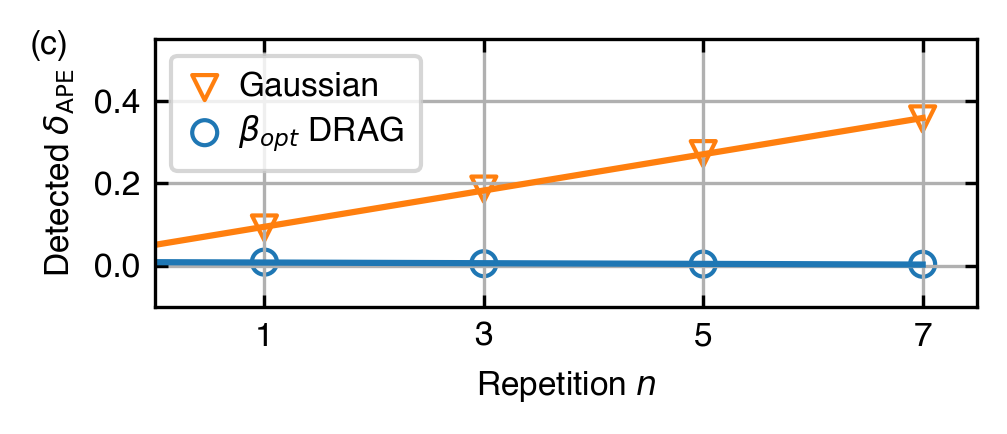

In [26]:
fig, ax = plt.subplots(figsize=(3.2, 1.3), nrows=1, layout='constrained')

ax.scatter(
    [1, 3, 5, 7], np.abs(init_phases['init_phases'][:4]), facecolor='none', edgecolor='tab:orange', marker='v', label=r'Gaussian'
)

ax.plot(
    [0, 1, 3, 5, 7], fit_init_phases['lin1'],
    color='tab:orange'
)

ax.scatter(
    [1, 3, 5, 7], np.abs(init_phases['init_phases'][4:]), facecolor='none', edgecolor='tab:blue', marker='o', label=r'$\beta_{opt}$ DRAG'
)

ax.plot(
    [0, 1, 3, 5, 7], fit_init_phases['lin2'],
    color='tab:blue'
)

ax.set_ylim(-0.1, 0.55)
ax.set_yticks([0, 0.2, 0.4])
ax.set_xlim(0, 7.5)
ax.set_xticks([1, 3, 5, 7])

ax.legend(fontsize=8, frameon=True, loc='upper left', handlelength=1, handletextpad=0.5, borderpad=0.5, labelspacing=0.3)

ax.set_ylabel(r'Detected $\delta_\text{APE}$', fontsize=8)
ax.tick_params(axis='both', which='major', top=True, right=True,
                length=3, direction='in', labelsize=8)

# ax.xaxis.set_minor_locator(AutoMinorLocator()) 
# ax.yaxis.set_minor_locator(AutoMinorLocator(2))  

ax.set_xlabel(r'Repetition $n$', fontsize=8)
ax.grid()

fig.text(0.0, 0.93, '(c)', fontsize=8)
# fig.tight_layout()

fig.savefig('./figures/main/3d_fit_init_phases.pdf', format='pdf', bbox_inches=0) 

# Figure 4. DRAG + APE

In [27]:
drag_ape_data = np.load('./data/drag_ape/drag_ape_data.npz')

drag_ape_data

NpzFile './data/drag_ape/drag_ape_data.npz' with keys: beta_swept, drape_pops, y_fit_pops

In [28]:
beta_swept = drag_ape_data['beta_swept']
drape_pops = drag_ape_data['drape_pops']
y_fit_pops = drag_ape_data['y_fit_pops']

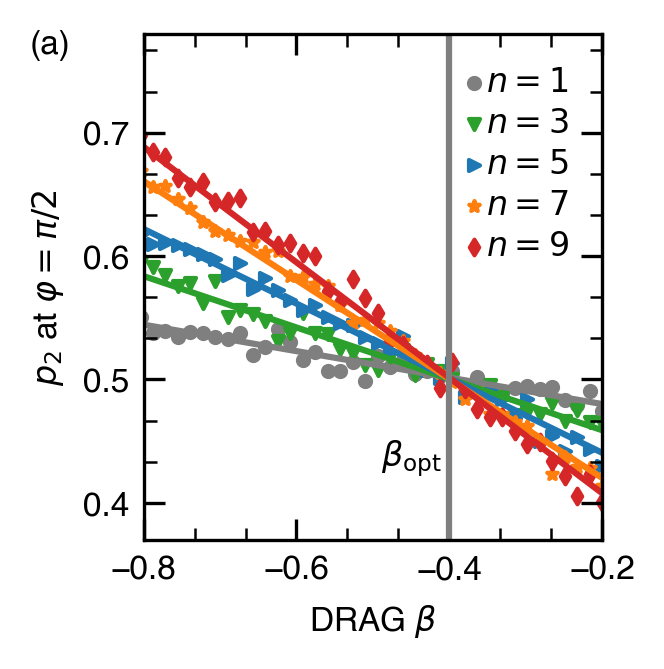

In [36]:
fig, ax = plt.subplots(figsize=(2.1, 2.1), layout='constrained')

my_colors = ['tab:gray', 'tab:green', 'tab:blue', 'tab:orange', 'tab:red', 'tab:cyan']
my_markers = ['o', 'v', '>', '*', 'd']

for i in [0, 1, 2, 3, 4]: 
    ax.scatter(beta_swept, drape_pops[i][:, 2], color=my_colors[i], s=7, marker=my_markers[i], label=f'$n={2*i+1}$')
    ax.plot(beta_swept, y_fit_pops[i], color=my_colors[i])

ax.axvline(-0.4, color='tab:gray')
ax.text(-0.45, 0.42, r'$\beta_\text{opt}$', fontsize=8, ha='center', va='bottom')

ax.set_ylim(0.37, 0.78)
# ax.set_yticks([0, 0.2, 0.4])
ax.set_xlim(-0.8, -0.2)
# ax.set_xticks([1, 3, 5, 7])

ax.legend(fontsize=8, frameon=False, loc='upper right', handlelength=0.1, handletextpad=0.3, borderpad=0.5, labelspacing=0.3, framealpha=1)

ax.set_ylabel(r'$p_2$ at $\varphi=\pi/2$', fontsize=8)
ax.tick_params(axis='both', which='major', top=True, right=True,
                length=5, direction='in', labelsize=8)

ax.xaxis.set_minor_locator(AutoMinorLocator(3)) 
ax.yaxis.set_minor_locator(AutoMinorLocator(3))  
ax.tick_params(axis='both', which='minor', top=True, right=True,
                length=3, direction='in')

ax.set_xlabel(r'DRAG $\beta$', fontsize=8)

fig.text(0.02, 0.95, '(a)', fontsize=8)

fig.savefig('./figures/main/drag_ape_sweep.pdf', format='pdf', bbox_inches=0) 

C:\Users\tng-admin\AppData\Local\Temp\ipykernel_6444\1527877578.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  b.fig.tight_layout()


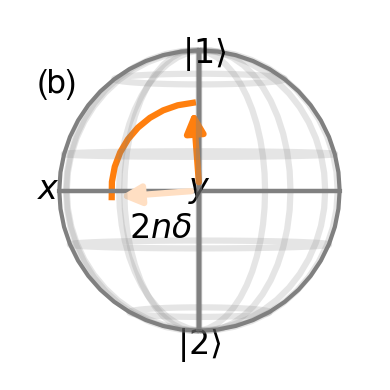

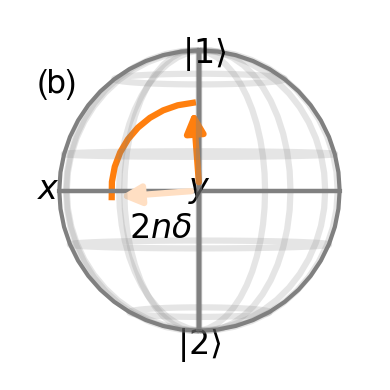

In [20]:
def Z(angle):
 theta = angle / 2
 return (-1j * theta * sz).expm()

def Udrag(angle):
 theta = angle / 2
 return (-1j * theta * sy).expm()

psi0 = Udrag(0.075)*Z(-np.pi/5) * ((basis(2, 0) + 1j * basis(2, 1)).unit())

b = Bloch(figsize=(1.1, 1.1))
b.vector_mutation = 10
b.vector_width = 1.5
b.xlpos = [1.075, -1.2]
b.zlpos = [1.2, -1.1]

states = []
bloch_coords = []

for angle in np.linspace(0, np.pi/2, 10):
    psi_N = Udrag(-angle)*psi0
    x = expect(sx, psi_N)
    y = expect(sy, psi_N)
    z = expect(sz, psi_N)
    bloch_coords.append([x, y, z])

states.append(psi0)
states.append(Udrag(-np.pi/2)*psi0)
# psi_axis = ((1/np.sqrt(2))*basis(2, 0) + (np.exp(1j*np.pi/4)/np.sqrt(2))*basis(2, 1)).unit()
# states.append(psi_axis)
# psi_axis = ((1/np.sqrt(2))*basis(2, 0) - (np.exp(1j*np.pi/4)/np.sqrt(2))*basis(2, 1)).unit()
# states.append(psi_axis)
# psi_axis = ((1/np.sqrt(2))*basis(2, 0) - (np.exp(1j*3*np.pi/4)/np.sqrt(2))*basis(2, 1)).unit()
# states.append(psi_axis)
# psi_axis = ((1/np.sqrt(2))*basis(2, 0) + (np.exp(1j*3*np.pi/4)/np.sqrt(2))*basis(2, 1)).unit()
# states.append(psi_axis)

# b.vector_color = ['tab:orange' for _ in range(len(states))]
b.vector_color.append('#FFDFC3')
b.vector_color.append('tab:orange')
# b.vector_color.append('tab:red')
# b.vector_color.append('tab:red')
# b.vector_color.append('tab:red')
# b.vector_color.append('tab:red')

xs, ys, zs = zip(*bloch_coords)
b.add_points([xs, ys, zs], meth='l', colors=['tab:orange' for _ in range(len(states))])  # trajectory as a line

# Add Bloch vectors
b.add_states(states)
b.view = [0, 0]
# Display the Bloch sphere
b.make_sphere()
b.font_size = 8
b.zlabel = [r'', r'$|2\rangle$']
b.sphere_alpha = 0
b.fig.text(0.3, 0.37, r'$2n\delta$', fontsize=8)
b.fig.text(0.46, 0.9, r'$|1\rangle$', fontsize=8)
b.fig.text(0.02, 0.81, '(b)', fontsize=8)
b.fig.tight_layout()
b.show()
# b.fig.savefig('./figures/main/ape_drag_visualize1.pdf', format='pdf', transparent=False, bbox_inches='tight', pad_inches=0.0)

C:\Users\tng-admin\AppData\Local\Temp\ipykernel_6444\3394158795.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  b.fig.tight_layout()


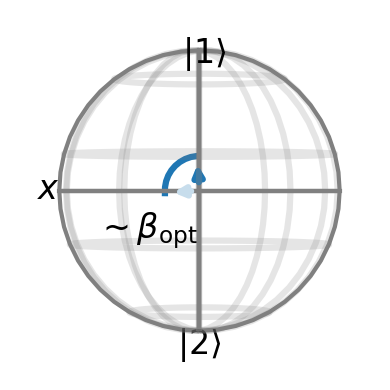

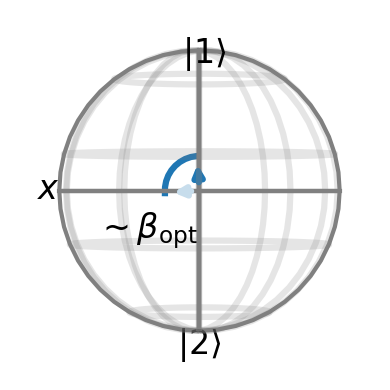

In [21]:
def Z(angle):
 theta = angle / 2
 return (-1j * theta * sz).expm()

def Udrag(angle):
 theta = angle / 2
 return (-1j * theta * sy).expm()

psi0 = Udrag(0.075)*Z(-0.23) * ((basis(2, 0) + 1j * basis(2, 1)).unit())

b = Bloch(figsize=(1.1, 1.1))
b.vector_mutation = 5
b.vector_width = 1.5
b.xlpos = [1.075, -1.2]
b.zlpos = [1.2, -1.1]

states = []
bloch_coords = []

for angle in np.linspace(0, np.pi/2, 10):
    psi_N = Udrag(-angle)*psi0
    x = expect(sx, psi_N)
    y = expect(sy, psi_N)
    z = expect(sz, psi_N)
    bloch_coords.append([x, y, z])

states.append(psi0)
states.append(Udrag(-np.pi/2)*psi0)
# psi_axis = ((1/np.sqrt(2))*basis(2, 0) + (np.exp(1j*np.pi/4)/np.sqrt(2))*basis(2, 1)).unit()
# states.append(psi_axis)
# psi_axis = ((1/np.sqrt(2))*basis(2, 0) - (np.exp(1j*np.pi/4)/np.sqrt(2))*basis(2, 1)).unit()
# states.append(psi_axis)
# psi_axis = ((1/np.sqrt(2))*basis(2, 0) - (np.exp(1j*3*np.pi/4)/np.sqrt(2))*basis(2, 1)).unit()
# states.append(psi_axis)
# psi_axis = ((1/np.sqrt(2))*basis(2, 0) + (np.exp(1j*3*np.pi/4)/np.sqrt(2))*basis(2, 1)).unit()
# states.append(psi_axis)

# b.vector_color = ['tab:orange' for _ in range(len(states))]
b.vector_color.append('#C7DDEC')
b.vector_color.append('tab:blue')
# b.vector_color.append('tab:red')
# b.vector_color.append('tab:red')
# b.vector_color.append('tab:red')
# b.vector_color.append('tab:red')

xs, ys, zs = zip(*bloch_coords)
b.add_points([xs, ys, zs], meth='l', colors=['tab:blue' for _ in range(len(states))])  # trajectory as a line

# Add Bloch vectors
b.add_states(states)
b.view = [0, 0]
# Display the Bloch sphere
b.ylabel = ['', '']
b.make_sphere()
b.font_size = 8
b.zlabel = [r'', r'$|2\rangle$']
b.sphere_alpha = 0
b.fig.text(0.2, 0.37, r'$\sim\beta_\text{opt}$', fontsize=8)
b.fig.text(0.46, 0.9, r'$|1\rangle$', fontsize=8)
b.fig.tight_layout()
b.show()
# b.fig.savefig('./figures/main/ape_drag_visualize2.pdf', format='pdf', transparent=False, bbox_inches='tight', pad_inches=0.0)

# Figure 5. Phase advance

In [38]:
import pickle 
with open('./data/phase_advance/rpc_figure5.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

In [39]:
loaded_dict

{'sequence length': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 'alpha01': [np.float64(5.375399555924391),
  np.float64(5.360170162533815),
  np.float64(5.358080554487072),
  np.float64(5.362811889900031),
  np.float64(5.3589830198388615),
  np.float64(5.358722480106413),
  np.float64(5.361467173204005),
  np.float64(5.359121613565769),
  np.float64(5.365491737827618),
  np.float64(5.3482172108034645),
  np.float64(5.350388565760632)],
 'alpha12': [np.float64(2.7581963390270827),
  np.float64(2.666281243259397),
  np.float64(2.697615047556327),
  np.float64(2.697429158932326),
  np.float64(2.7046864597749147),
  np.float64(2.6977497647601734),
  np.float64(2.7122469343331517),
  np.float64(2.699722780740303),
  np.float64(2.6936631630122636),
  np.float64(2.7201289895699263),
  np.float64(2.6979201844236775)]}

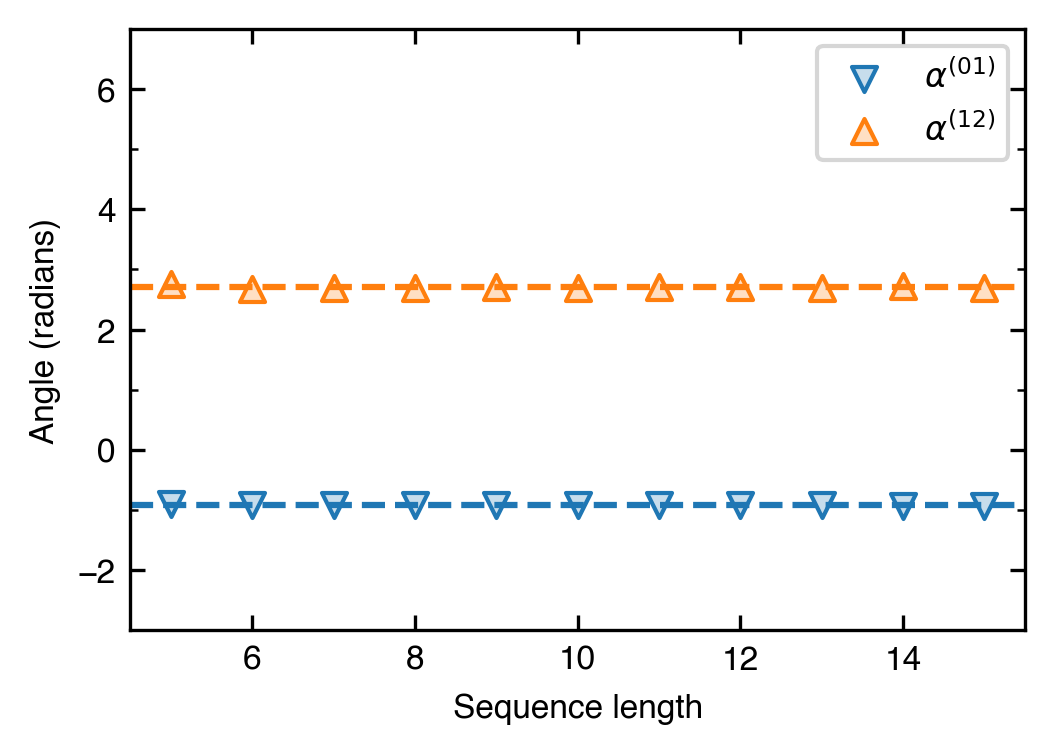

In [41]:
fig, ax = plt.subplots(figsize=(3.4, 2.4), layout='constrained')

ax.scatter(
    loaded_dict['sequence length'], np.array(loaded_dict['alpha01'])-2*np.pi,
    label=r'$\alpha^{(01)}$', facecolor='#C7DDEC', edgecolor='tab:blue', marker='v'
)

ax.axhline(2.7, linestyle='--', color='tab:orange')

ax.scatter(
    loaded_dict['sequence length'], loaded_dict['alpha12'],
    label=r'$\alpha^{(12)}$', facecolor='#FFDFC3', edgecolor='tab:orange', marker='^'
)

ax.axhline(-0.923, linestyle='--', color='tab:blue')

ax.set_ylim(-3, 7)
# ax.set_yticks([0, 0.2, 0.4])
# ax.set_xlim(0, 7.5)
# ax.set_xticks([1, 3, 5, 7])

ax.legend(fontsize=8)

ax.set_ylabel(r'Angle (radians)', fontsize=8)
ax.set_xlabel(r'Sequence length', fontsize=8)

ax.tick_params(axis='both', which='both', top=True, right=True,direction='in', labelsize=8)

ax.yaxis.set_minor_locator(AutoMinorLocator(2))  

# ax.grid()

# for spine in ax.spines.values():
#     spine.set_linewidth(1.5)

# fig.text(0.04, 0.97, '(c)', fontsize=17)

fig.savefig('./figures/appendix/phase_advance_rpc.pdf', format='pdf', bbox_inches=0) 

# Figure 6. Randomized benchmarking

In [42]:
rb_clifford_uc = np.load('./data/rb/rb_uc.npz')
rb_clifford_c = np.load('./data/rb/rb_c.npz')
rb_pi12_uc = np.load('./data/rb/rb_pi12_uc.npz')
rb_pi12_c = np.load('./data/rb/rb_pi12_c.npz')
rb_H_uc = np.load('./data/rb/rb_H_uc.npz')
rb_H_c = np.load('./data/rb/rb_H_c.npz')

In [43]:
rb_clifford_c['depth_arr'].shape

(33,)

In [44]:
rb_clifford_uc.files

['depth_arr',
 'm_fit',
 'p0',
 'p1',
 'p2',
 'expectZ',
 'fit_vals_0',
 'fit_vals_1',
 'fit_vals_2',
 'fit_vals',
 'f_fit',
 'std']

In [45]:
def e_F(p, d):
    return (1-p)*(1-1/d**2)

def e_gate(p_i, p, d):
    return (1-1/d**2)*(1-p_i/p)

def expectZ(p0, p1, p2):
    return p0 + np.exp(2*np.pi*1j/3) * p1 + np.exp(4*np.pi*1j/3) * p2

In [46]:
p0 = [0.7215464673156661,
0.7750679618875861,
0.8152026936487753,
0.7484984529778824,
0.831795545329245,
0.571317612468928,
0.6675828228334014,
0.7881027542002575,
0.7695113432489118,
0.4798286142143496,
0.5155072559738186,
0.5390124064796219,
0.7055191327928387,
0.6625590790019098,
0.6643136883359825,
0.5427773713309468,
0.7899977779508016,
0.644842435043702,
0.45431013039976503,
0.39527447753358136]

p1 = [0.3284824463133765,
0.3381555237286019,
0.231479966900628,
0.2539372538137423,
0.3158686966195268,
0.2955870913447576,
0.37143731737882746,
0.24661353817931359,
0.297166143219014,
0.25333889863615067,
0.2874746105286361,
0.24865779974602262,
0.26452836409055214,
0.29301328322667974,
0.32424157270574344,
0.3949635342805167,
0.28187657216740286,
0.24766287202399806,
0.2708705887329193,
0.4230146613132033]

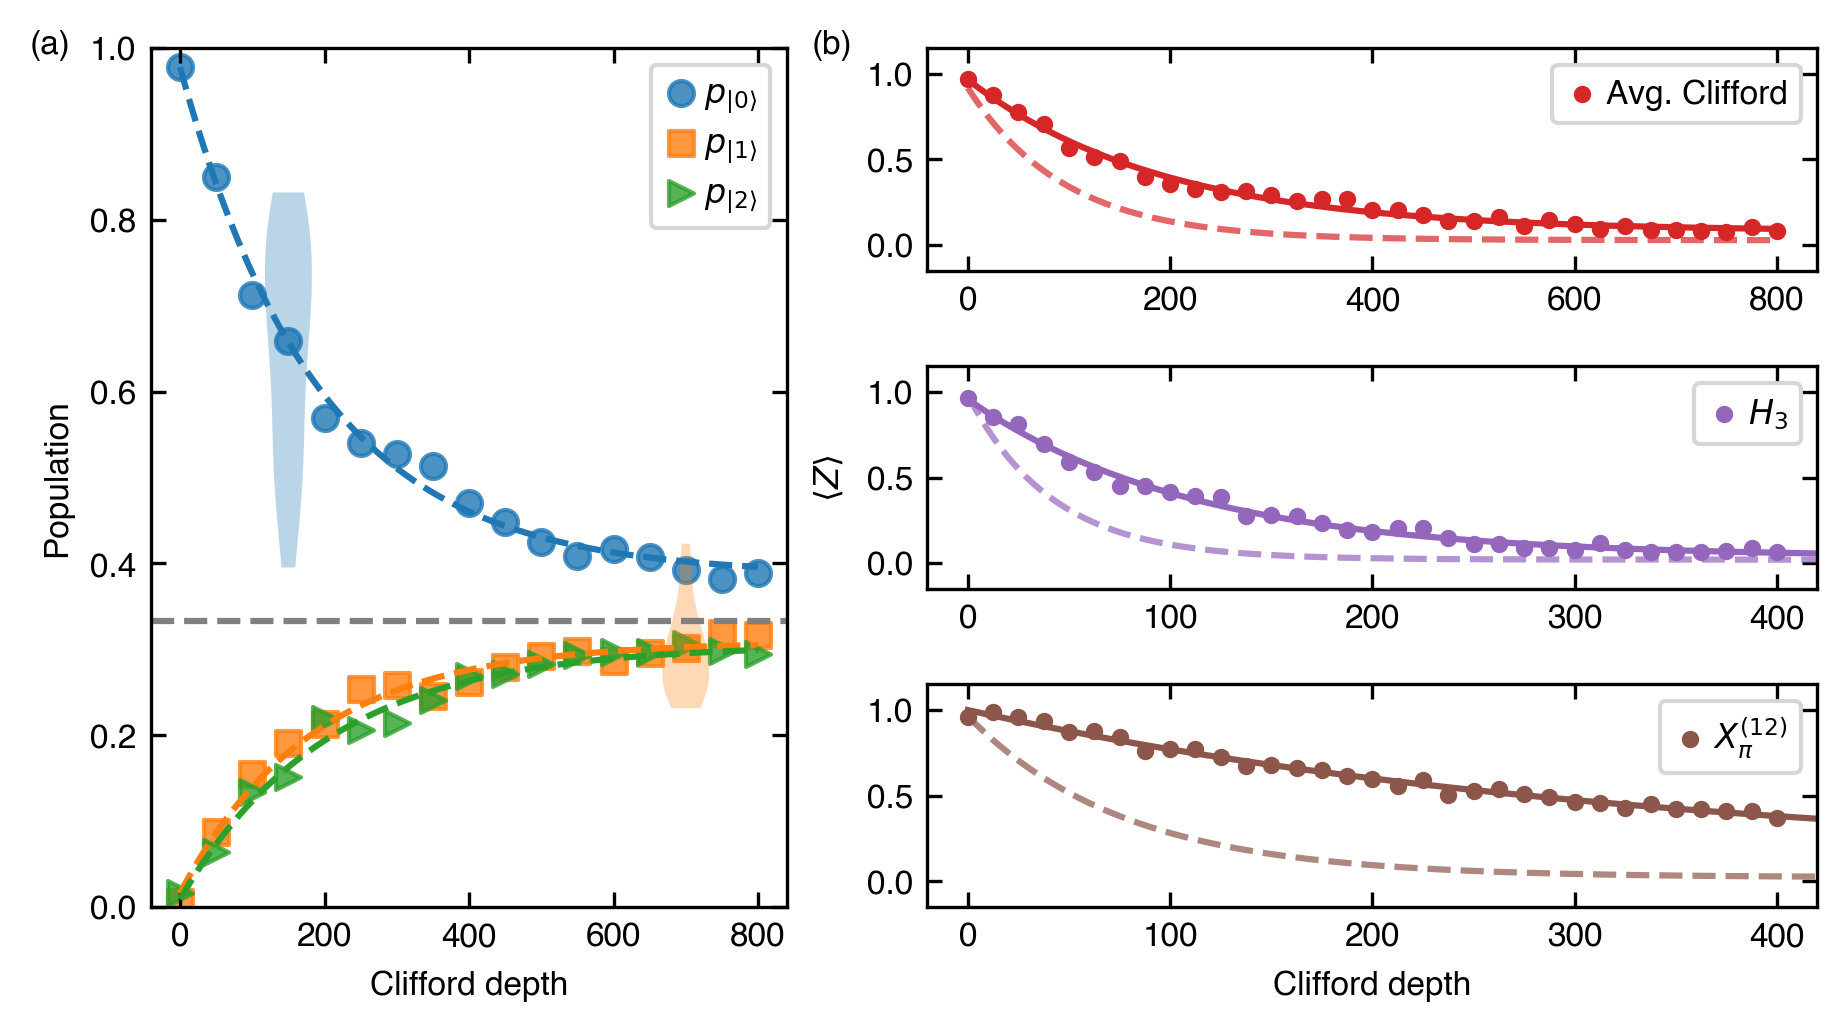

In [49]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

fig = plt.figure(figsize=(6, 3.3), layout='constrained')
gs = GridSpec(3, 2, width_ratios=[1, 1.4], figure=fig)


ax_left = fig.add_subplot(gs[:, 0])

ax_bottom_right = fig.add_subplot(gs[2, 1])
ax_top_right = fig.add_subplot(gs[0, 1])
ax_mid_right = fig.add_subplot(gs[1, 1])

skip_clifford_c = 2
skip_expZ = 1

ax_left.scatter(rb_clifford_c['depth_arr'][::skip_clifford_c], rb_clifford_c['p0'][::skip_clifford_c], alpha=0.8, label=r'$p_{|0\rangle}$', marker='o')
ax_left.plot(rb_clifford_c['m_fit'], rb_clifford_c['fit_vals_0'], '--', color='tab:blue')
ax_left.scatter(rb_clifford_c['depth_arr'][::skip_clifford_c], rb_clifford_c['p1'][::skip_clifford_c], alpha=0.8, label=r'$p_{|1\rangle}$', marker='s')
ax_left.plot(rb_clifford_c['m_fit'], rb_clifford_c['fit_vals_1'], '--', color='tab:orange')
ax_left.scatter(rb_clifford_c['depth_arr'][::skip_clifford_c], rb_clifford_c['p2'][::skip_clifford_c], alpha=0.8, label=r'$p_{|2\rangle}$', marker='>')
ax_left.plot(rb_clifford_c['m_fit'], rb_clifford_c['fit_vals_2'], '--', color='tab:green')
ax_left.violinplot(p0, positions=[150], widths=65, showextrema=False)
ax_left.violinplot(p1, positions=[700], widths=65, showextrema=False)

ax_left.axhline(0.333333333, linestyle='--', color='gray')
ax_left.set_ylim(0, 1)
ax_left.set_xlabel(r'Clifford depth')
ax_left.set_ylabel(r'Population')

ax_top_right.scatter(rb_clifford_c['depth_arr'][::skip_expZ], rb_clifford_c['expectZ'][::skip_expZ], label='Avg. Clifford', color='tab:red', alpha=1, s=10)
ax_top_right.plot(rb_clifford_c['m_fit'], rb_clifford_c['fit_vals'], color='tab:red')
ax_top_right.plot(rb_clifford_c['m_fit'], rb_clifford_uc['fit_vals'], color='tab:red', alpha=0.7, linestyle='--')
ax_top_right.set_ylim(-0.15, 1.15)

ax_mid_right.scatter(rb_H_c['depth_arr'][::skip_expZ], rb_H_c['expectZ'][::skip_expZ], label=r'$H_3$', color='tab:purple', alpha=1, s=10)
ax_mid_right.plot(rb_H_c['m_fit'], rb_H_c['fit_vals'], color='tab:purple')
ax_mid_right.plot(rb_H_c['m_fit'], rb_H_uc['fit_vals'], color='tab:purple', alpha=0.7, linestyle='--')
ax_mid_right.set_ylabel(r'$\langle Z\rangle$', labelpad=5)
ax_mid_right.set_ylim(-0.15, 1.15)
ax_mid_right.set_xlim(-20, 420)

ax_bottom_right.scatter(rb_pi12_c['depth_arr'][::skip_expZ], rb_pi12_c['expectZ'][::skip_expZ], label=r'$X_{\pi}^{(12)}$', color='tab:brown', alpha=1, s=10)
ax_bottom_right.plot(rb_pi12_c['m_fit'], rb_pi12_c['fit_vals'], color='tab:brown')
ax_bottom_right.plot(rb_pi12_c['m_fit'], rb_pi12_uc['fit_vals'], color='tab:brown', alpha=0.7, linestyle='--')
ax_bottom_right.set_xlabel(r'Clifford depth')
ax_bottom_right.set_ylim(-0.15, 1.15)
ax_bottom_right.set_xlim(-20, 420)

for ax in [ax_left, ax_bottom_right, ax_mid_right, ax_top_right]:
    ax.tick_params(axis='both', which='major', top=True, right=True, direction='in')
    ax.legend(frameon=True, loc='upper right',
              handlelength=1, handletextpad=0.2,
              borderpad=0.4, labelspacing=0.4, fontsize=8)

fig.text(0.0, 0.97, '(a)', fontsize=8)
fig.text(0.434, 0.97, '(b)', fontsize=8)
fig.savefig('./figures/main/rb.pdf', format='pdf', bbox_inches=0)
plt.show()

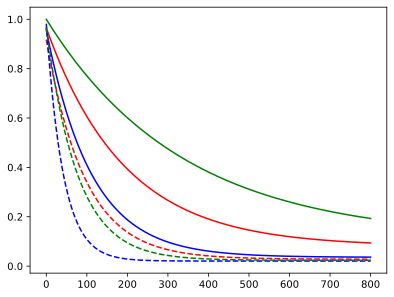

In [24]:
plt.plot(rb_clifford_uc['m_fit'], rb_clifford_uc['fit_vals'], '--', color='red')
plt.plot(rb_clifford_c['m_fit'], rb_clifford_c['fit_vals'], color='red')

plt.plot(rb_H_uc['m_fit'], rb_H_uc['fit_vals'], '--', color='blue')
plt.plot(rb_H_c['m_fit'], rb_H_c['fit_vals'], color='blue')

plt.plot(rb_pi12_uc['m_fit'], rb_pi12_uc['fit_vals'], '--', color='green')
plt.plot(rb_pi12_c['m_fit'], rb_pi12_c['fit_vals'], color='green')

In [27]:
uc_clifford_average_error = e_F(rb_clifford_uc['f_fit'], 3)
c_clifford_average_error = e_F(rb_clifford_c['f_fit'], 3)

print(uc_clifford_average_error/1e-3, rb_clifford_uc['std']/1e-3,  c_clifford_average_error/1e-3, rb_clifford_c['std']/1e-3)

9.259817526700981 0.5127296425797433 4.603541839100167 0.1859628361623219


In [36]:
h3uc_infidelity = e_gate(rb_H_uc['f_fit'], rb_clifford_uc['f_fit'], d=3)

std_h3uc = h3uc_infidelity * np.sqrt((rb_H_uc['std']/rb_H_uc['f_fit'])**2+(rb_clifford_uc['std']/rb_clifford_uc['f_fit'])**2)

print(h3uc_infidelity/1e-2, std_h3uc/1e-2)

1.1859798914047794 0.0010723529355989316


In [37]:
h3c_infidelity = e_gate(rb_H_c['f_fit'], rb_clifford_c['f_fit'], d=3)

std_h3c = h3c_infidelity * np.sqrt((rb_H_c['std']/rb_H_c['f_fit'])**2+(rb_clifford_c['std']/rb_clifford_c['f_fit'])**2)

print(h3c_infidelity/1e-3, std_h3c/1e-3)

3.3845526744813936 0.001224892234728402


In [45]:
pi12uc_infidelity = e_gate(rb_pi12_uc['f_fit'], rb_clifford_uc['f_fit'], d=3)

std_pi12uc = pi12uc_infidelity * np.sqrt((rb_pi12_uc['std']/rb_pi12_uc['f_fit'])**2+(rb_clifford_uc['std']/rb_clifford_uc['f_fit'])**2)

print(pi12uc_infidelity/1e-3, std_pi12uc/1e-3)

2.164044901638166 0.0013487539705986972


In [46]:
pi12c_infidelity = e_gate(rb_pi12_c['f_fit'], rb_clifford_c['f_fit'], d=3)

std_pi12c = pi12c_infidelity * np.sqrt((rb_pi12_c['std']/rb_pi12_c['f_fit'])**2+(rb_clifford_c['std']/rb_clifford_c['f_fit'])**2)

print(pi12c_infidelity/1e-3, std_pi12c/1e-3)

-1.9705738436852884 -0.000644642450939194


In [47]:
rb_pi12_uc['f_fit'], rb_pi12_c['f_fit']

(array(0.98717352), array(0.99702643))